# Sparse autoencoder demo

Take one image. Run it through the full classifier. Then run it through the sparse
autoencoder bottleneck (backbone -> encoder -> decoder -> classifier head) and check
the prediction still holds up. Everything is shown for a single seeded image.

In [2]:
from pathlib import Path
import random

import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

from embedding import EfficientNetB0, MobileNetV2
from sae import SparseAutoEncoder

# pick which trained autoencoder to look at, and which image
SAE_PATH = Path(
    "./output/efficientnet_adamw_l10.0004_lr0.001_x32_e200_b4096_n100000_seed0/sae.pt"
)
DATASET_ID = "ILSVRC/imagenet-1k"
SEED = 0
TOPK = 5

MODELS = {"efficientnet": EfficientNetB0, "mobilenet": MobileNetV2}
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: mps


In [3]:
# load the autoencoder checkpoint, then load the matching classifier model
ckpt = torch.load(SAE_PATH, weights_only=True)
model_name = ckpt["config"]["model"]
model = MODELS[model_name](device=device)
id2label = model.model.config.id2label

sae = SparseAutoEncoder(ckpt["d_input"], ckpt["n_features"]).to(device)
sae.load_state_dict(ckpt["state_dict"])
sae.eval()
mean = ckpt["normalizer_mean"].to(device)  # (d_input,) the training mean vector
n_features = ckpt["n_features"]

print("model:", model_name)
print("embedding size:", ckpt["d_input"])
print("sparse features:", n_features)


def class_name(i):
    # the label map can have int or str keys, so try both
    return id2label.get(i, id2label.get(str(i), str(i)))


def show_topk(logits, k=TOPK):
    logits = logits.flatten()
    probs = logits.softmax(0)
    values, indices = logits.topk(k)
    for rank, (i, v) in enumerate(zip(indices.tolist(), values.tolist()), start=1):
        print(f"  {rank}. {class_name(i)[:40]:40s}  logit {v:6.2f}  p {probs[i]:.3f}")
    return indices[0].item()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model: efficientnet
embedding size: 1280
sparse features: 40960


## Load a random image

Same seed gives the same image every time.

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

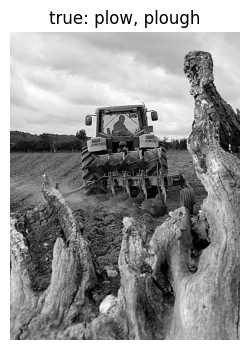

true label: 730 - plow, plough


In [4]:
# stream the validation split and grab one image, chosen by the seed
offset = random.Random(SEED).randint(0, 199)
stream = load_dataset(DATASET_ID, split="validation", streaming=True).skip(offset).take(1)
example = next(iter(stream))
image = example["image"].convert("RGB")
label = example["label"]

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.title(f"true: {class_name(label)}")
plt.show()
print("true label:", label, "-", class_name(label))

## Full model prediction

Image straight through the whole classifier.

In [5]:
with torch.no_grad():
    logits_full = model.forward([image])  # (1, 1000)

print("full model top-k:")
top1_full = show_topk(logits_full)
print("\ncorrect" if top1_full == label else "\nwrong")

full model top-k:
  1. jeep, landrover                           logit   8.13  p 0.360
  2. plow, plough                              logit   7.48  p 0.188
  3. tractor                                   logit   6.99  p 0.114
  4. harvester, reaper                         logit   6.30  p 0.058
  5. snowplow, snowplough                      logit   6.27  p 0.056

wrong


## Through the sparse autoencoder

Backbone gives the embedding. We normalize it the same way training did
(subtract the mean, scale to unit norm), run the encoder and decoder, then put the
normalization back so the classifier head sees a normal embedding again.

In [6]:
with torch.no_grad():
    embedding = model.forward_to_embedding([image])  # (1, d_input) raw embedding
    centered = embedding - mean                       # (1, d_input)
    norm = centered.norm(dim=-1, keepdim=True)        # (1, 1) the length we remove
    x = centered / norm                               # (1, d_input) unit norm input

    sparse = sae.encode(x)                            # (1, n_features) sparse code
    recon = sae.decode(sparse)                        # (1, d_input) in normalized space
    embedding_back = recon * norm + mean              # (1, d_input) back to raw space
    logits_recon = model.forward_from_embedding(embedding_back)  # (1, 1000)

active = int((sparse > 0).sum())
recon_error = ((x - recon) ** 2).sum().item()
sparsity_l1 = sparse.abs().sum().item()

print(f"active features: {active} / {n_features}  ({100 * active / n_features:.2f}% on)")
print(f"reconstruction error: {recon_error:.4f}")
print(f"sparsity (L1 of features): {sparsity_l1:.2f}")
print()
print("reconstructed embedding top-k:")
top1_recon = show_topk(logits_recon)
print("\ncorrect" if top1_recon == label else "\nwrong")

active features: 1704 / 40960  (4.16% on)
reconstruction error: 0.0078
sparsity (L1 of features): 54.72

reconstructed embedding top-k:
  1. jeep, landrover                           logit   8.11  p 0.360
  2. plow, plough                              logit   7.49  p 0.194
  3. tractor                                   logit   6.91  p 0.109
  4. snowplow, snowplough                      logit   6.31  p 0.060
  5. harvester, reaper                         logit   6.14  p 0.050

wrong


## Compare

Do the full model and the autoencoder path agree on the top classes?

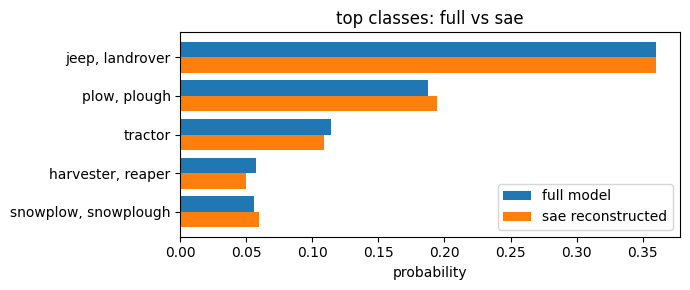

true label       : 730 plow, plough
full model top-1 : 609 jeep, landrover
sae path top-1   : 609 jeep, landrover

the sae keeps the same prediction


In [7]:
# bars: for the full model's top classes, how much probability does each path give?
top_idx = logits_full.flatten().topk(TOPK).indices.tolist()
probs_full = logits_full.flatten().softmax(0)[top_idx].tolist()
probs_recon = logits_recon.flatten().softmax(0)[top_idx].tolist()
names = [class_name(i)[:22] for i in top_idx]
y = np.arange(len(top_idx))

plt.figure(figsize=(7, 3))
plt.barh(y - 0.2, probs_full, height=0.4, label="full model")
plt.barh(y + 0.2, probs_recon, height=0.4, label="sae reconstructed")
plt.yticks(y, names)
plt.gca().invert_yaxis()
plt.xlabel("probability")
plt.title("top classes: full vs sae")
plt.legend()
plt.tight_layout()
plt.show()

print(f"true label       : {label} {class_name(label)}")
print(f"full model top-1 : {top1_full} {class_name(top1_full)}")
print(f"sae path top-1   : {top1_recon} {class_name(top1_recon)}")
print()
print("the sae keeps the same prediction" if top1_recon == top1_full else "the prediction changed")